In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import(classification_report,confusion_matrix,
                              roc_auc_score,roc_curve,precision_recall_curve,
                              average_precision_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [ ]:
cc=pd.read_csv('/content/creditcard.csv')

In [ ]:
cc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
cc.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
cc.shape

(284807, 31)

In [ ]:
cc.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [ ]:
cc.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
cc.value_counts()

Time      V1          V2          V3         V4         V5         V6         V7          V8          V9         V10        V11        V12        V13        V14        V15        V16        V17        V18        V19        V20        V21         V22        V23        V24        V25        V26        V27        V28        Amount  Class
163152.0  -1.203617    1.574009    2.889277   3.381404   1.538663   3.698747   0.560211   -0.150911    0.124136   4.220998   1.384569  -0.706897  -0.256274  -1.562583   1.692915  -0.787338  -0.226776  -0.412354   0.234322   1.385597  -0.366727    0.522223  -0.357329  -0.870174  -0.134166   0.327019  -0.042648  -0.855262  1.51    0        18
          -1.196037    1.585949    2.883976   3.378471   1.511706   3.717077   0.585362   -0.156001    0.122648   4.217934   1.385525  -0.709405  -0.256168  -1.564352   1.693218  -0.785210  -0.228008  -0.412833   0.234834   1.375790  -0.370294    0.524395  -0.355170  -0.869790  -0.133198   0.327804  -0.035702  -0.858197  7.56    0        18
43153.0   -2.086016    2.203265    1.654339   2.941050  -1.683045   0.529728  -1.352162    1.793449   -0.723686   0.600365  -0.982212  -0.551636  -1.337000   0.834403   1.251862   0.033455   1.067978   0.160510   0.213087   0.079002   0.216444    0.567241  -0.035345   0.370201   0.157378   0.440341   0.210230   0.090558  0.76    0         9
170731.0   2.033492    0.766969   -2.107555   3.631952   1.348594  -0.499907   0.945159   -0.286392   -1.370581   1.653073  -1.600434  -1.510901  -2.143280   1.189850  -0.875588   0.175808  -0.419433  -0.464717  -1.414528  -0.430560   0.241894    0.658545  -0.102644   0.580535   0.643637   0.347240  -0.116618  -0.078601  0.76    0         9
68207.0   -13.192671   12.785971  -9.906650   3.320337  -4.801176   5.760059  -18.750889  -37.353443  -0.391540  -5.052502   4.406806  -4.610756  -1.909488  -9.072711  -0.226074  -6.211557  -6.248145  -3.149247   0.051576  -3.493050   27.202839  -8.887017   5.303607  -0.639435   0.263203  -0.108877   1.269566   0.939407  1.00    1         6
                                                                                                                                                                                                                                                                                                                                                    ..
65147.0   -2.639726   -1.681328    1.679737  -0.330078  -0.190618  -1.229356  -0.768137    0.789063    0.910798  -1.227234  -1.527674  -0.463425  -1.907133   0.077571  -0.745780   0.314541   0.156432  -0.192560  -0.268854   0.621215   0.056716   -0.647958   0.220882   0.386474  -0.100074   0.784748   0.116465  -0.196321  134.56  0         1
65146.0   -0.527468    0.518935    1.532247   0.127781   0.104476   0.706109   0.328273    0.441650    0.449801  -0.571205   0.296344   1.012209  -0.430863  -0.396291  -2.113819  -0.322739  -0.262472  -0.206551  -0.599815  -0.065819   0.014978    0.392326  -0.107604  -0.298394  -0.000313  -0.500540   0.355964   0.116452  33.55   0         1
          -1.311257    1.594149    0.333083  -0.220284  -0.015917  -0.379755   0.858647    0.357080   -0.635483  -0.767855  -1.502618   0.148063   0.698339   0.422342   0.134920   0.638694  -0.870763   0.167561  -0.750061  -0.354109   0.129079    0.255574  -0.261871  -0.450986   0.236772  -0.539048  -0.524133  -0.257155  76.73   0         1
65145.0   -1.947319   -0.414360    1.168998   0.351236   0.652473  -1.213314   0.164272    0.085646   -0.533949  -0.438583   0.129482   0.608604   0.683578   0.268744   0.976465  -0.233258   0.092155  -0.978496  -0.364467  -0.021927  -0.031539   -0.222027  -0.291861   0.469980  -0.556953   0.168018  -0.150882  -0.429461  59.22   0         1
65148.0   -0.713014    1.190692    1.573727  -0.153580  -0.102880  -0.697982   0.635247    0.043104   -0.563704   0.148276   1.603311   1.021464   0.485765   0.166393   0.086832   0.289450  -0.611823  -0.010564   0.193182   0.260650 

In [ ]:
print(cc['Class'].value_counts(normalize=True)*100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [ ]:
col=list(cc.columns)

In [ ]:
# Drops only the rows containing any missing values
cc_cleaned = cc.dropna(axis=0)


In [ ]:
for i in col:
  if cc[i].dtype == object:
    print(i)

In [ ]:
for i in col:
  if cc[i].dtype == int:
    print(i)

Class


In [ ]:
for i in col:
  if cc[i].dtype == float:
    print(i)

Time
V1
V2
V3
V4
V5
V6
V7
V8
V9
V10
V11
V12
V13
V14
V15
V16
V17
V18
V19
V20
V21
V22
V23
V24
V25
V26
V27
V28
Amount


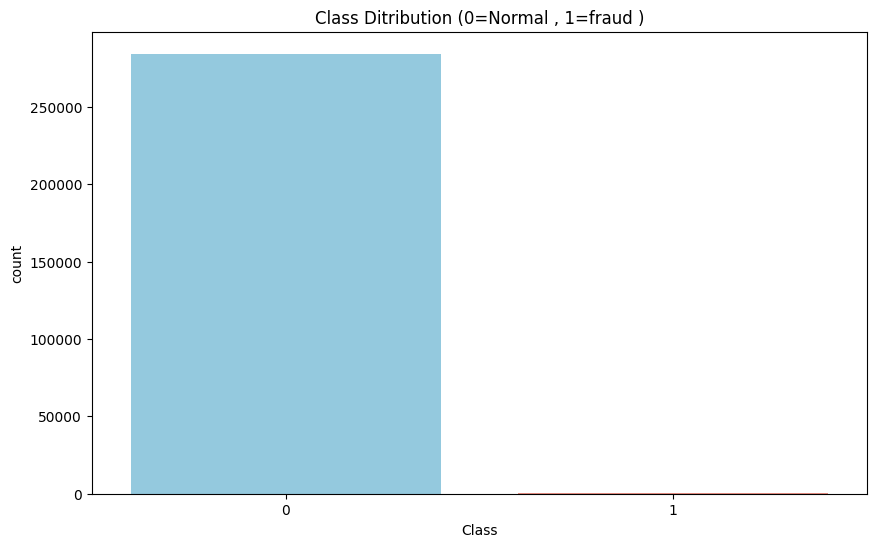

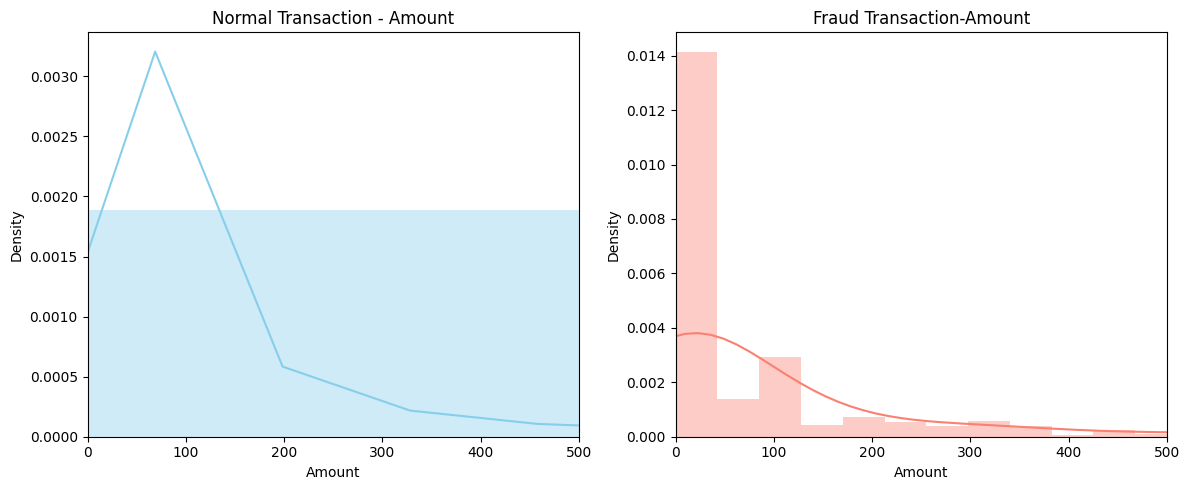

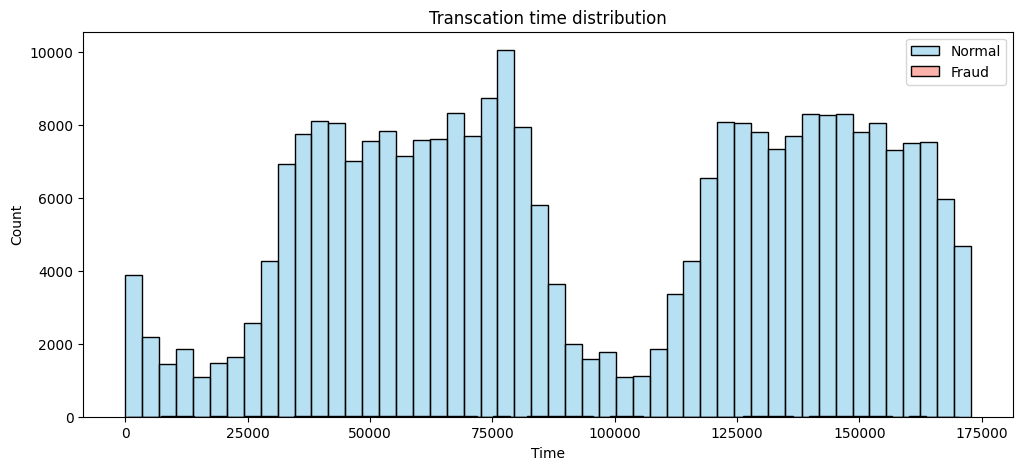

In [ ]:
#class Distribution
plt.figure(figsize=(10,6))
sns.countplot(x='Class',data=cc,palette=['skyblue','salmon'])
plt.title('Class Ditribution (0=Normal , 1=fraud )')
plt.xlabel('Class')
plt.ylabel('count')
plt.show()


#Transaction amount distribution
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.distplot(cc[cc['Class']==0]['Amount'],bins=50,color='skyblue',kde=True)
plt.title('Normal Transaction - Amount')
plt.xlim([0,500])

plt.subplot(1,2,2)
sns.distplot(cc[cc['Class']==1]['Amount'],bins=50,color='salmon',kde=True)
plt.title('Fraud Transaction-Amount')
plt.xlim([0,500])

plt.tight_layout()

plt.show()



#Time Distribution
plt.figure(figsize=(12,5))

sns.histplot(cc[cc['Class']==0]['Time'],bins=50,color='skyblue',label='Normal',alpha=0.6)
sns.histplot(cc[cc['Class']==1]['Time'],bins=50,color='salmon',label="Fraud",alpha=0.6)
plt.title('Transcation time distribution')
plt.legend()
plt.show()


In [ ]:
X=cc.drop(['Class'], axis=1)
Y=cc['Class']

scalar= StandardScaler()
X['Amount']= scalar.fit_transform(X[['Amount']])
X['Time']=Scalar.fit_transform(X[['Time']])

print('Features shape',X.shape)
print('Target Shape', Y.shape)
print('\n Class Distribution in Target :')
print(Y.value_counts())

Features shape (284807, 30)
Target Shape (284807,)

 Class Distribution in Target :
Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,
                                               random_state=42,
                                               stratify=y)

In [ ]:
print(X_train)
print(X_test)
print(Y_train)
print(Y_test)
print(Y_train.value_counts())
print(Y_test.value_counts())

            Time        V1        V2  ...       V27       V28    Amount
265518  1.413095  1.946747 -0.752526  ...  0.077641 -0.032248 -0.323963
180305  0.624644  2.035149 -0.048880  ...  0.002520 -0.069002 -0.341275
42664  -1.129186 -0.991920  0.603193  ...  0.038049  0.185340  0.346835
198723  0.796203  2.285718 -1.500239  ...  0.018045 -0.063005 -0.328841
82325  -0.746606 -0.448747 -1.011440  ... -0.032580 -0.064194 -0.008994
...          ...       ...       ...  ...       ...       ...       ...
233802  1.113883  1.993864 -0.516866  ... -0.032455 -0.058552 -0.329281
85418  -0.717019 -1.497933  0.657921  ... -0.448445  0.045178 -0.205340
29062  -1.253217  1.069777  0.072105  ...  0.031014  0.024886 -0.171636
13766  -1.482496  1.280465  0.300586  ... -0.059835 -0.005887 -0.349671
17677  -1.389125 -0.598120  0.775041  ...  0.378580  0.206366 -0.325283

[227845 rows x 30 columns]
            Time        V1        V2  ...       V27       V28    Amount
263020  1.388689 -0.674466  1.408105

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, Y_train_res = smote.fit_resample(X_train, Y_train)

print("Before SMOTE - Training class distribution:")
print(Y_train.value_counts())
print("\nAfter SMOTE - Training class distribution:")
print(pd.Series(Y_train_res).value_counts())


Before SMOTE - Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE - Training class distribution:
Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
logmodel=LogisticRegression(class_weight='balanced',
                            max_iter=1000,
                            random_state=42,
                            n_jobs=-1)
logmodel.fit(X_train_res,Y_train_res)
y_pred_log = logmodel.predict(X_test)
y_prob_log = logmodel.predict_proba(X_test)[:, 1]



In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    max_depth=10
)

rf_model.fit(X_train_res, Y_train_res)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully!")

Random Forest trained successfully!



Evaluation for: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

Confusion Matrix:
[[55406  1458]
 [    8    90]]


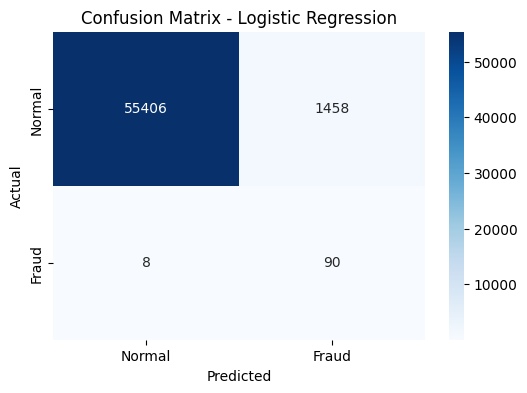

ROC-AUC Score: 0.9698
Average Precision Score: 0.7249

Evaluation for: Random Forest

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.43      0.88      0.58        98

    accuracy                           1.00     56962
   macro avg       0.71      0.94      0.79     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56749   115]
 [   12    86]]


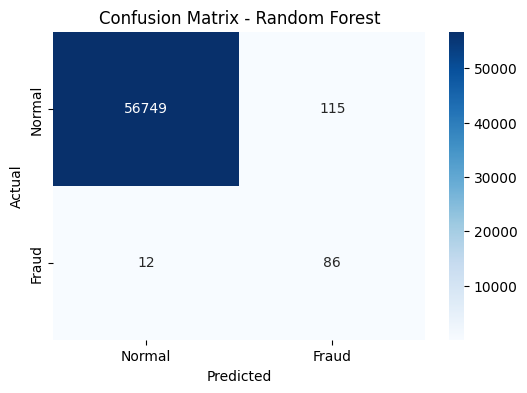

ROC-AUC Score: 0.9836
Average Precision Score: 0.8075


In [ ]:
def evaluate_model(Y_true, y_pred, y_prob, model_name):
    print(f"\n{'='*50}")
    print(f"Evaluation for: {model_name}")
    print(f"{'='*50}")

    print("\nClassification Report:")
    print(classification_report(Y_true, y_pred, target_names=['Normal', 'Fraud']))

    print("Confusion Matrix:")
    cm = confusion_matrix(Y_true, y_pred)
    print(cm)

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ROC-AUC
    roc_auc = roc_auc_score(Y_true, y_prob)
    print(f"ROC-AUC Score: {roc_auc:.4f}")

    # Average Precision (better for imbalanced data)
    ap = average_precision_score(Y_true, y_prob)
    print(f"Average Precision Score: {ap:.4f}")

# Evaluate Logistic Regression
evaluate_model(Y_test, y_pred_log, y_prob_log, "Logistic Regression")

# Evaluate Random Forest
evaluate_model(Y_test, y_pred_rf, y_prob_rf, "Random Forest")

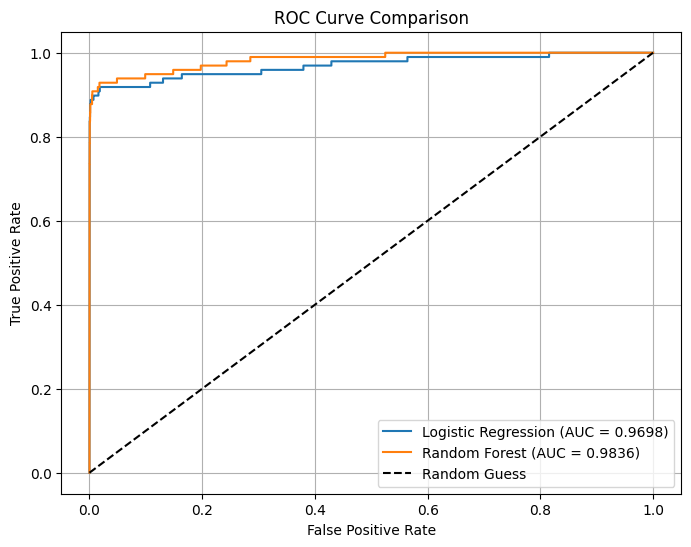

In [ ]:
fpr_log, tpr_log, _ = roc_curve(Y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(Y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_score(Y_test, y_prob_log):.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(Y_test, y_prob_rf):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()


Top 10 Most Important Features:


,Feature,Importance
14,V14,0.198965
10,V10,0.114902
4,V4,0.107073
12,V12,0.103600
17,V17,0.091901
3,V3,0.067095
11,V11,0.060482
16,V16,0.044117
2,V2,0.038663
9,V9,0.025654


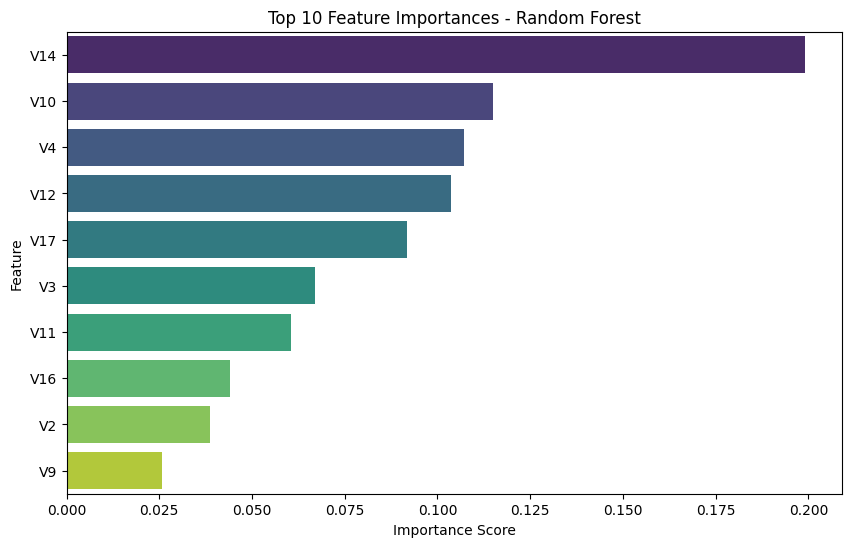

In [ ]:
importance_cc = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top 10 Most Important Features:")
display(importance_cc.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_cc.head(10), palette='viridis')
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.show()

In [ ]:

threshold = 0.3

y_pred_custom = (y_prob_rf >= threshold).astype(int)

print(f"Results with threshold = {threshold}")
print(classification_report(Y_test, y_pred_custom, target_names=['Normal', 'Fraud']))
print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred_custom))

Results with threshold = 0.3
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     56864
       Fraud       0.15      0.91      0.26        98

    accuracy                           0.99     56962
   macro avg       0.58      0.95      0.63     56962
weighted avg       1.00      0.99      0.99     56962

Confusion Matrix:
[[56371   493]
 [    9    89]]
